## **DATA 575 - HW 6**
Train and evaluate the model, then implement the attention strategy near the end of the page.

Make the following changes to the code:

- Replace the embeddings with pretrained word embeddings such as word2vec, Fastext, or GloVe.
- Try 3 experiments with more layers,  or more hidden units. Compare the training time and results.

### **Additional Notes:**


*  Used fastext as my pretrained word embeddings. I ran into errors with memory usage, so after some research and help from Claude, I implemented fastext cc.en.300 and cc.fr.300 word vectors from .vec files.
*  I used fastext because it provides pretrained word vectors for both English and French.

In [ ]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
SOS_token = 0
EOS_token = 1

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [ ]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

In [ ]:
def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")

    # Read the file and split into lines
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').\
        read().strip().split('\n')

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [ ]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
        len(p[1].split(' ')) < MAX_LENGTH and \
        p[1].startswith(eng_prefixes)


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [ ]:
# Getting data
import os, urllib.request, zipfile

os.makedirs('data', exist_ok=True)
if not os.path.exists('data/eng-fra.txt'):
    urllib.request.urlretrieve(
        'https://download.pytorch.org/tutorial/data.zip', 'data.zip'
    )
    with zipfile.ZipFile('data.zip') as z:
        z.extractall('.')

In [ ]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['elle cherche un meilleur emploi', 'she s looking for a better job']


### **Replacing Embeddings with Pre-Trained Word Embeddings**
- Beginning changes to the original PyTorch tutorial.

In [43]:
# Matrix Function

import unicodedata

def build_embedding_matrix(lang, vec_path, dim, ascii_fold=False):
    matrix = np.random.normal(scale=0.1, size=(lang.n_words, dim)).astype(np.float32)
    needed = lang.word2index
    filled = set()
    with open(vec_path, encoding='utf-8', newline='\n', errors='ignore') as f:
        next(f)  # skip header line
        for line in f:
            word, rest = line.split(' ', 1)
            if ascii_fold:
                word = unicodeToAscii(word.lower())
            if word in needed and needed[word] not in filled:
                vec = np.asarray(rest.split(' ')[:dim], dtype=np.float32)
                if len(vec) == dim:
                    matrix[needed[word]] = vec
                    filled.add(needed[word])
    print(f"{lang.name}: {len(filled)}/{lang.n_words} words found")
    return torch.tensor(matrix)

In [59]:
# The Encoder
class EncoderRNN(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, num_layers=1, dropout_p=0.1, freeze=True):
        super(EncoderRNN, self).__init__()
        emb_dim = embedding_matrix.size(1)
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze)
        self.gru = nn.GRU(emb_dim, hidden_size, num_layers=num_layers, batch_first=True,
                          dropout=dropout_p if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

In [45]:
# The Decoder
class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden  = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None # We return `None` for consistency in the training loop

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

In [60]:
# Attention Decoder
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, embedding_matrix, hidden_size, output_size, num_layers=1, dropout_p=0.1, freeze=True):
        super(AttnDecoderRNN, self).__init__()
        emb_dim = embedding_matrix.size(1)
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(emb_dim + hidden_size, hidden_size, num_layers=num_layers, batch_first=True,
                          dropout=dropout_p if num_layers > 1 else 0)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        query = hidden[-1].unsqueeze(1)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

In [47]:
# Preparing Training Data
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)

    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(torch.LongTensor(input_ids).to(device),
                               torch.LongTensor(target_ids).to(device))

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
    return input_lang, output_lang, train_dataloader

In [48]:
# Training the Model
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
          decoder_optimizer, criterion):

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [49]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

In [50]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001,
               print_every=100, plot_every=100):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)
    return plot_losses # For the 3 experiments

In [87]:
# Plotting Results
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

In [52]:
# Evaluation
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

In [53]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

### **Now Implementing Fastext**

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 77.0 MB/s eta 0:00:00


In [ ]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz
!gunzip cc.en.300.vec.gz cc.fr.300.vec.gz

--2026-10-08 23:58:34--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.86.101.115, 99.86.101.39, 99.86.101.24, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.86.101.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1325960915 (1.2G) [binary/octet-stream]
Saving to: ‘cc.en.300.vec.gz’

cc.en.300.vec.gz    100%[===================>]   1.23G   174MB/s    in 6.7s    

2026-10-08 23:58:41 (188 MB/s) - ‘cc.en.300.vec.gz’ saved [1325960915/1325960915]

--2026-10-08 23:58:41--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.86.101.115, 99.86.101.39, 99.86.101.24, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.86.101.115|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1287757366 (1.2G) [binary/octet-stream]
Saving to: ‘cc.fr

In [61]:
# Training and Evaluating

batch_size = 32

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

# Build matrices (English = decoder, French = encoder)

# English
en_matrix = build_embedding_matrix(output_lang, 'cc.en.300.vec', 300)


# French
fr_matrix = build_embedding_matrix(input_lang, 'cc.fr.300.vec', 300, ascii_fold=True)

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
eng: 2986/2991 words found
fra: 4578/4601 words found


### **Three Experiments**

*   Experiment #1: Hidden units - 256, Layer - 1
*   Experiment #2: Hidden units - 512, Layer - 1
*   Experiment #3: Hidden units - 128, Layer - 2



In [74]:
results = []

In [75]:
# 3 Experiments

def run_experiment(name, hidden_size, num_layers, n_epochs=40, freeze = False):
    torch.manual_seed(0)
    encoder = EncoderRNN(fr_matrix, hidden_size, num_layers).to(device)
    decoder = AttnDecoderRNN(en_matrix, hidden_size, output_lang.n_words, num_layers).to(device)
    n_params = sum(p.numel() for m in (encoder, decoder) for p in m.parameters() if p.requires_grad)

    start = time.time()
    losses = train(train_dataloader, encoder, decoder, n_epochs, print_every=5, plot_every=5)
    elapsed = time.time() - start

    print(f"\n{name}: {elapsed:.0f}s, {n_params:,} trainable params, final loss {losses[-1]:.4f}")
    return {"name": name, "time": elapsed, "params": n_params, "final_loss": losses[-1],
            "encoder": encoder, "decoder": decoder}


In [77]:
# Original
results.append(run_experiment("Baseline h128 L1", 128, 1))

1m 0s (- 7m 3s) (5 12%) 1.8776
2m 3s (- 6m 11s) (10 25%) 1.0932
3m 10s (- 5m 17s) (15 37%) 0.7266
4m 12s (- 4m 12s) (20 50%) 0.4975
5m 13s (- 3m 8s) (25 62%) 0.3521
6m 15s (- 2m 5s) (30 75%) 0.2579
7m 16s (- 1m 2s) (35 87%) 0.1953
8m 17s (- 0m 0s) (40 100%) 0.1523

Baseline h128 L1: 497s, 798,384 trainable params, final loss 0.1523


In [79]:
# Experiment 1
results.append(run_experiment("h256 L1", 256, 1))

1m 5s (- 7m 36s) (5 12%) 1.6092
2m 9s (- 6m 29s) (10 25%) 0.6875
3m 13s (- 5m 21s) (15 37%) 0.3182
4m 22s (- 4m 22s) (20 50%) 0.1589
5m 35s (- 3m 21s) (25 62%) 0.0928
6m 47s (- 2m 15s) (30 75%) 0.0658
8m 1s (- 1m 8s) (35 87%) 0.0545
9m 15s (- 0m 0s) (40 100%) 0.0468

h256 L1: 556s, 1,954,224 trainable params, final loss 0.0468


In [81]:
# Experiment 2
results.append(run_experiment("h512 L1", 512, 1))

1m 12s (- 8m 28s) (5 12%) 1.2719
2m 27s (- 7m 22s) (10 25%) 0.2987
3m 33s (- 5m 56s) (15 37%) 0.1050
4m 39s (- 4m 39s) (20 50%) 0.0700
5m 50s (- 3m 30s) (25 62%) 0.0573
7m 6s (- 2m 22s) (30 75%) 0.0525
8m 13s (- 1m 10s) (35 87%) 0.0494
9m 20s (- 0m 0s) (40 100%) 0.0467

h512 L1: 560s, 5,347,248 trainable params, final loss 0.0467


In [82]:
# Experiment 3
results.append(run_experiment("h128 L2", 128, 2))

1m 20s (- 9m 20s) (5 12%) 1.9681
2m 42s (- 8m 8s) (10 25%) 1.1607
4m 3s (- 6m 45s) (15 37%) 0.8084
5m 20s (- 5m 20s) (20 50%) 0.5830
6m 42s (- 4m 1s) (25 62%) 0.4312
8m 1s (- 2m 40s) (30 75%) 0.3259
9m 19s (- 1m 19s) (35 87%) 0.2543
10m 39s (- 0m 0s) (40 100%) 0.2026

h128 L2: 639s, 996,528 trainable params, final loss 0.2026


### **Comparison of Time and Results**

In [83]:
# Comparision of Time and Loss
for r in results:
    print(f"\n=== {r['name']} ===")
    r["encoder"].eval()
    r["decoder"].eval()
    random.seed(0)
    evaluateRandomly(r["encoder"], r["decoder"], n=5)

# Summary table
print(f"\n{'run':<20}{'time (s)':>10}{'params':>14}{'final loss':>12}")
for r in results:
    print(f"{r['name']:<20}{r['time']:>10.0f}{r['params']:>14,}{r['final_loss']:>12.4f}")


=== Baseline h128 L1 ===
> nous sommes du meme cote
= we re on the same side
< we re on the same side <EOS>

> il se plaint tout le temps
= he is always complaining
< he s always complaining about it <EOS>

> je suis consciencieux
= i m thorough
< i am poor father <EOS>

> je suis mediocre au tennis
= i am poor at tennis
< i am poor at tennis tennis <EOS>

> je ne suis pas autorisee a t aider
= i m not allowed to help you
< i m not allowed to help you <EOS>


=== h256 L1 ===
> nous sommes du meme cote
= we re on the same side
< we re the same same side <EOS>

> il se plaint tout le temps
= he is always complaining
< he is always complaining <EOS>

> je suis consciencieux
= i m thorough
< i am very <EOS>

> je suis mediocre au tennis
= i am poor at tennis
< i am poor at tennis <EOS>

> je ne suis pas autorisee a t aider
= i m not allowed to help you
< i m not allowed to help you <EOS>


=== h512 L1 ===
> nous sommes du meme cote
= we re on the same side
< we re the same same them as a 

### **Visualization of Attention**
*   Fair warning, there's a lot of graphs.
*   Summary of results and conclusions is after the graphs, scoll to the bottom for those!



In [95]:
# Visualizing Attention
def showAttention(input_sentence, output_words, attentions, title=None):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') +
                       ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # Labels
    ax.set_xlabel("Input (French)")
    ax.xaxis.set_label_position('top')
    ax.set_ylabel("Output (English)")
    if title:
        ax.set_title(title, pad=80)   # pad keeps it above the rotated x labels

    plt.show()


def evaluateAndShowAttention(encoder, decoder, input_sentence, title=None):
    encoder.eval()
    decoder.eval()
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words,
                  attentions[0, :len(output_words), :],
                  title=f"{title}\n{' '.join(output_words)}" if title else None)


=== Baseline h128 L1 ===
input = il n est pas aussi grand que son pere
output = he is not as tall as his brother <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


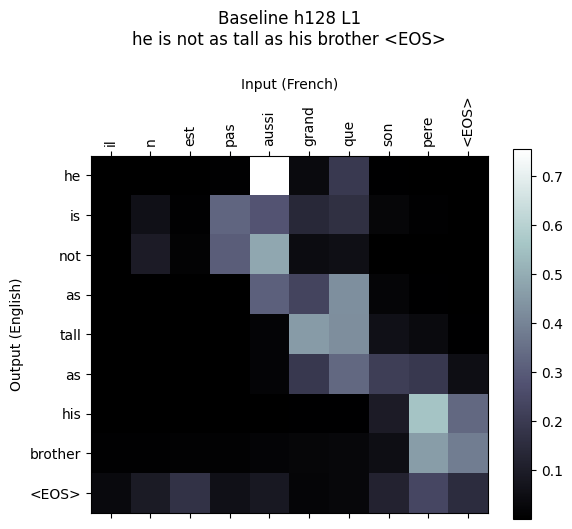

input = je suis trop fatigue pour conduire
output = i m too tired to drive any more <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


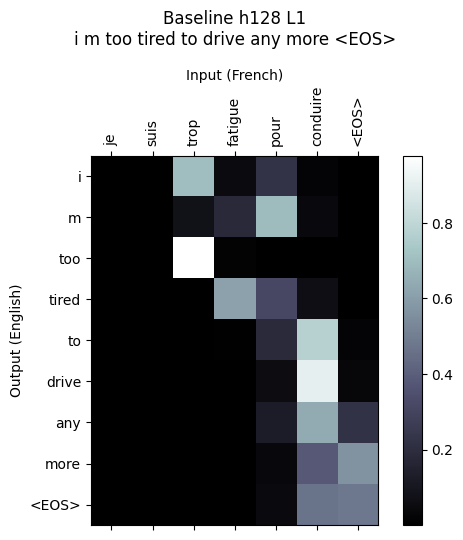

input = je suis desole si c est une question idiote
output = i m sorry if this is a stupid question <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


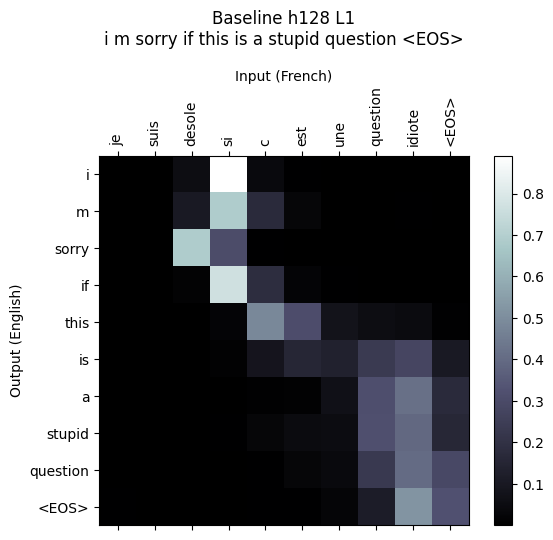

input = je suis reellement fiere de vous
output = i m really proud of you happy <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


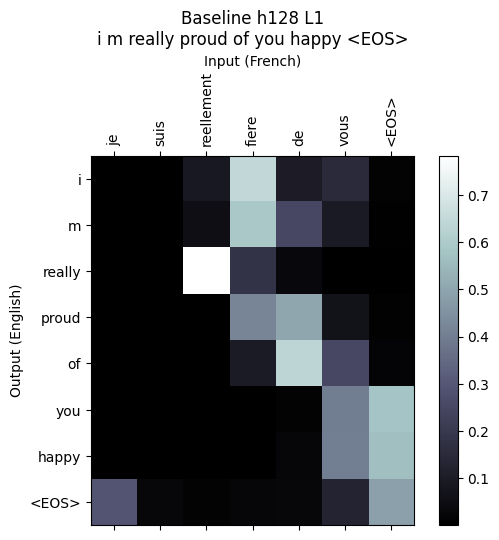


=== h256 L1 ===
input = il n est pas aussi grand que son pere
output = he is not as tall as his brother <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


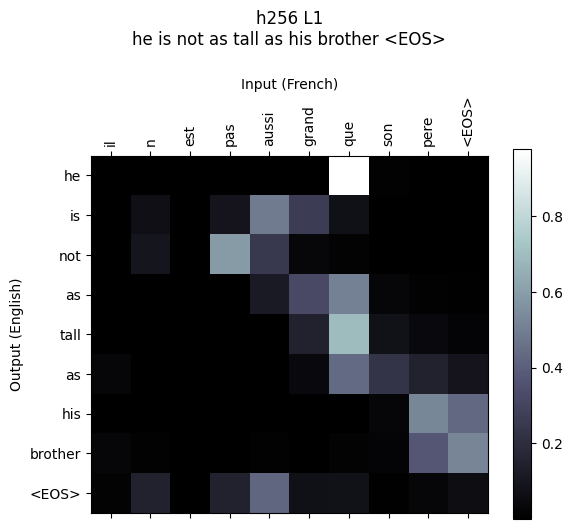

input = je suis trop fatigue pour conduire
output = i am too tired to drive any further <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


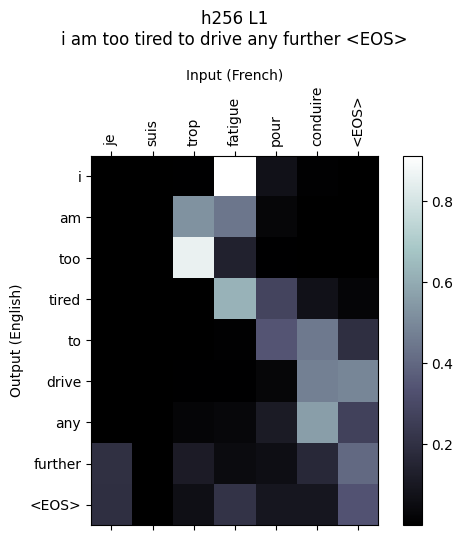

input = je suis desole si c est une question idiote
output = i m sorry if this is a stupid question <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


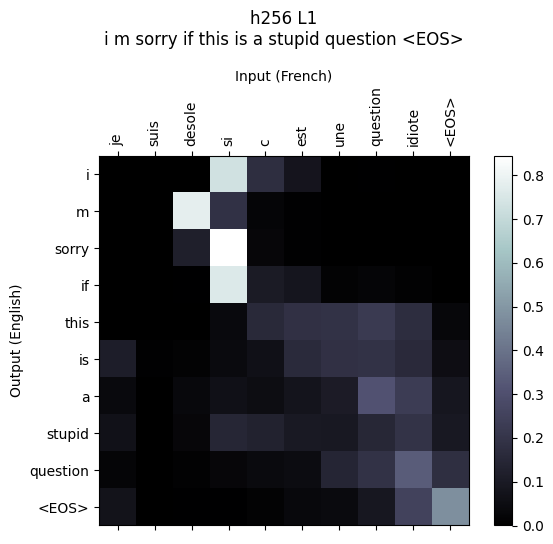

input = je suis reellement fiere de vous
output = i m so proud of you are <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


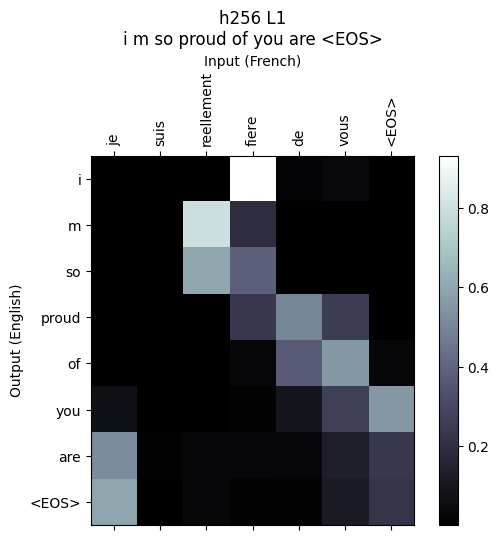


=== h512 L1 ===
input = il n est pas aussi grand que son pere
output = he is not as tall as his father <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


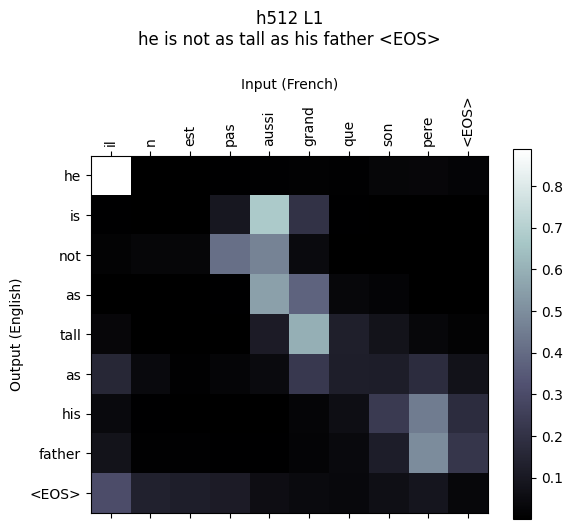

input = je suis trop fatigue pour conduire
output = i m too tired to drive any further <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


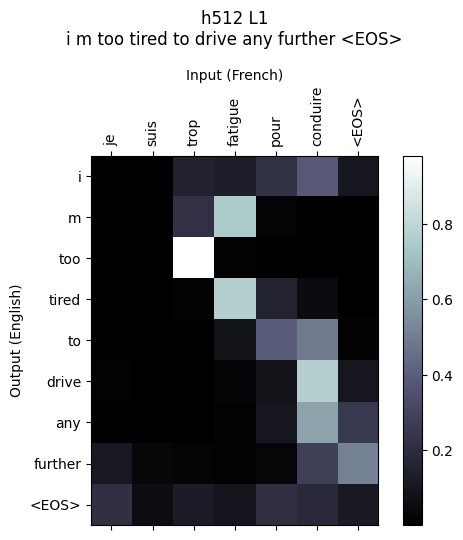

input = je suis desole si c est une question idiote
output = i m sorry if this is a stupid question <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


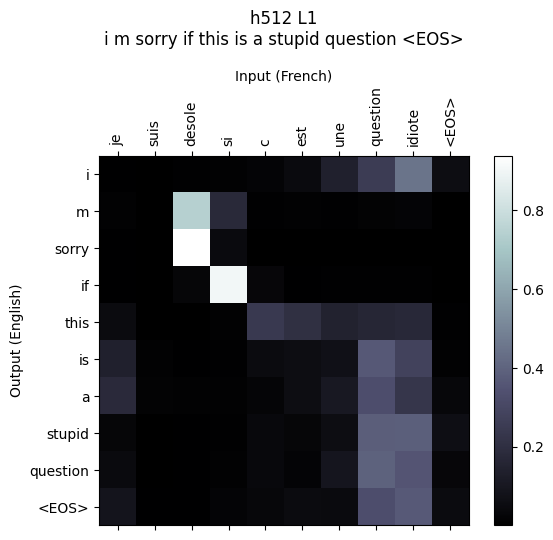

input = je suis reellement fiere de vous
output = i m really proud of you <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


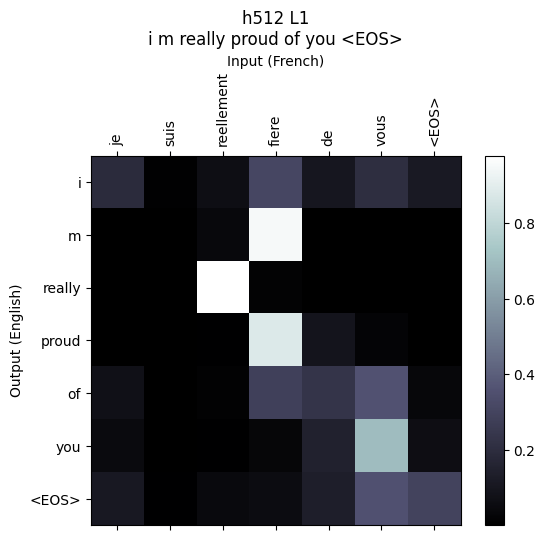


=== h128 L2 ===
input = il n est pas aussi grand que son pere
output = he is not as tall as his brother <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


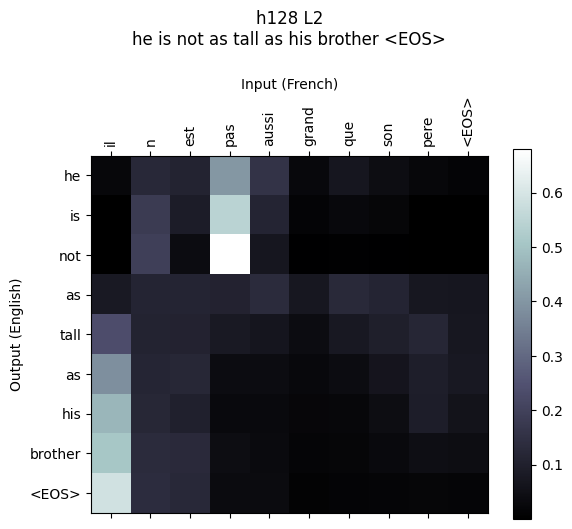

input = je suis trop fatigue pour conduire
output = i m too tired to walk so <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


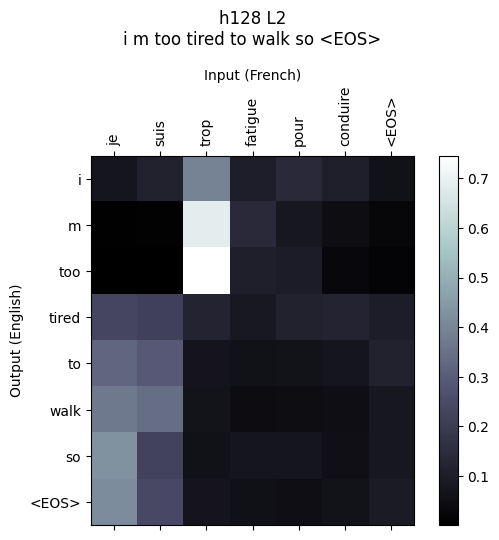

input = je suis desole si c est une question idiote
output = i m sorry if this is a stupid question <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


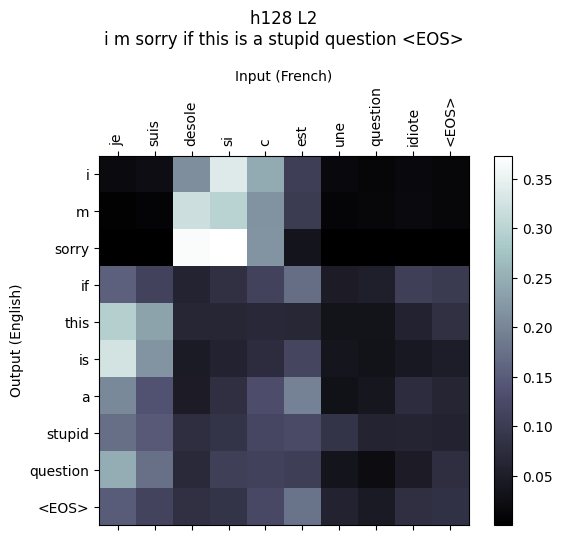

input = je suis reellement fiere de vous
output = i m so proud of you are mine <EOS>


/tmp/ipykernel_6501/2963646429.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
/tmp/ipykernel_6501/2963646429.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


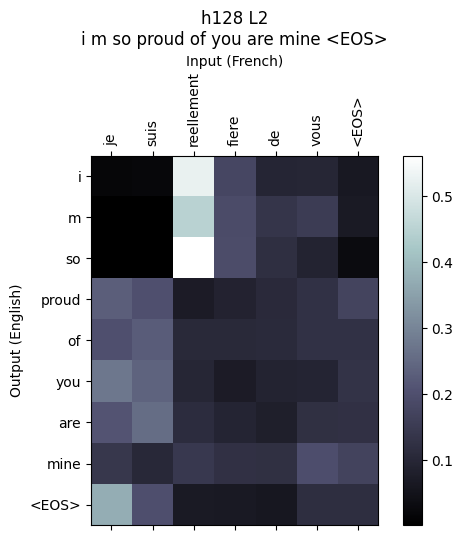

In [96]:
sentences = [
    "il n est pas aussi grand que son pere",
    "je suis trop fatigue pour conduire",
    "je suis desole si c est une question idiote",
    "je suis reellement fiere de vous",
]

for r in results:
    print(f"\n=== {r['name']} ===")
    for s in sentences:
        evaluateAndShowAttention(r["encoder"], r["decoder"], s, title=r["name"])

### **Summary of Results**

*   **Time**: Compared to Baseline, we see the most change in time mainly in Experiment #1 and Experiment #3. Increasing the hidden units, but not the layers, from 128 to 256, increased the run time from 497 seconds to 556 seconds. Between Experiment #1 and #2, there is less of a difference. The run time only increased by 4 seconds, despite doubling the hidden units. Adding a second layer had a much larger effect. From Baseline to Experiment #3, we see an increase in run time from 497 seconds to 639 seconds.
*   **Loss**: While run time increased with the experiments, we see a significantly better loss value when hidden units increase.
Looking at a change in hidden units, we see from Baseline to Experiment #1 that the loss goes from 0.1523 to 0.0468. From Experiment #1 to Experiment #2, we see barely any change in the loss, going from 0.0468 to 0.0467. Looking at Experiment #3, we see the opposite change from Baseline. The loss value goes from 0.1523 for Baseline to 0.2026 for Experiment #3.
*  **Conclusion**: Overall, it is apprarent that Experiment #1, with 256 hidden units and one layer, had the best balance between run time and loss. It cut the Baseline's loss from 0.1523 to 0.0468, with only a 59 second increase in run time. Although Experiment #2 isn't worse, we see that by doubling the hidden units, the loss was almost the same but with over double the parameter count.

